# Survival Analysis — Customer Churn

---
## Project Overview

**Objective:** Understand *when* and *why* customers churn using survival analysis techniques.
Complements the binary classification model in `3a)Data_Preprocessing_Models_Churn` by adding a temporal dimension.

**Data:** `mask_pay` — customers with at least one settlement event (67,440 customers).
Every customer in this population has a known outcome and duration, making censoring a non-issue.

| Variable | Description |
|----------|-------------|
| `TIME_TO_CHURN_D` | Duration of last contract until settlement (days) |
| `IS_CHURN` | Event indicator: 1 = churned, 0 = returned within 30 days (censored) |

---

## Notebook Structure

| # | Section | Description |
|---|---------|-------------|
| 0 | [Set Up](#0.-SET-UP) | Imports, constants, paths |
| 1 | [Load Dataset](#1.-LOAD-DATASET) | Load ABT, filter to mask_pay |
| 1.5 | [Preprocessing](#1.5-PREPROCESSING) | Outlier handling, imputation, OHE |
| 2 | [Kaplan-Meier](#2.-KAPLAN-MEIER) | Overall survival curve + group comparisons |
| 3 | [Cox PH Model](#3.-COX-PROPORTIONAL-HAZARDS-MODEL) | Hazard ratios per feature |
| 4 | [Summary](#4.-SUMMARY) | Key findings & business implications |

---
## 0. SET UP

In [11]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import src.code.io_utils as io_utils

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

from src.code.class_pipeline_functions import (
    ClientOutlierHandler,
    ClientImputer,
    ClientOneHotEncoder,
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

CLIENT_PATH = io_utils.output_path('prepared/abt.parquet')

---
## 1. LOAD DATASET

In [12]:
abt = io_utils.load(CLIENT_PATH)

# Filter to customers with settlement history (training population)
mask_pay = abt[abt[["EVER_SAN", "EVER_SOL", "EVER_RBT"]].eq(1).any(axis=1)].copy()

print(f"Total ABT:   {len(abt):,}")
print(f"mask_pay:    {len(mask_pay):,}")
print(f"IS_CHURN=1:  {mask_pay['IS_CHURN'].sum():,}  ({mask_pay['IS_CHURN'].mean():.1%})")
print(f"IS_CHURN=0:  {(mask_pay['IS_CHURN']==0).sum():,}  ({(mask_pay['IS_CHURN']==0).mean():.1%})")
print()
print("TIME_TO_CHURN_D stats (churned only):")
print(mask_pay.loc[mask_pay['IS_CHURN']==1, 'TIME_TO_CHURN_D'].describe().round(1))

[LOAD] /Users/eliaskarle/Coding/Nova/BusinessCases_1/Business_Case_BNP/data/prepared/abt.parquet | shape: (148729, 91)
Total ABT:   148,729
mask_pay:    67,440
IS_CHURN=1:  49,733  (73.7%)
IS_CHURN=0:  17,707  (26.3%)

TIME_TO_CHURN_D stats (churned only):
count    49733.0
mean      1710.7
std       1672.2
min          0.0
25%        636.0
50%       1241.0
75%       2196.0
max      10140.0
Name: TIME_TO_CHURN_D, dtype: float64


---
## 2. PREPROCESSING

Applies the same three preprocessing steps used in `3a)Data_Preprocessing_Models_Churn`
to ensure the Cox feature matrix is cleaned consistently.

1. **`ClientOutlierHandler`** — IQR + Modified Z-score voting (both must agree). Outliers → NaN, handled by the imputer next.
2. **`ClientImputer`** — Fills NaN with training-derived medians (no global leakage).
3. **`ClientOneHotEncoder`** — Encodes `CSP`, `PRODALP`, `sdem_SITFAM`, `sdem_HABITAT`. Without this step these columns are silently dropped by `select_dtypes(include='number')` in Section 3.

`mask_pay` is left **untouched** — KM reads duration/event/group columns directly from it.
`prep_df` is the preprocessed feature matrix consumed by the Cox model in Section 3.

In [24]:
# ── 1. Preprocessing — consistent with 3a pipeline ──────────────────────────
LEAKY = [
    # Target and direct leakage
    "IS_CHURN",                   # the label itself
    'HAS_ACTIVE',             # leak: directly correlates with active status (inverse of churn)
    'EVER_SAN',               # leak: directly reveals SAN history
    'EVER_SOL',               # leak: directly reveals SOL history
    'N_SAN',                  # leak: count of SAN events
    'N_SOL',                  # leak: count of SOL events
    'EVER_RBT',               # leak: reveals RBT (reimbursement) events
    'N_RBT',                  # leak: count of RBT events
    'IS_SAN',                 # leak: binary SAN flag
    'IS_EARLY_SETTLER',       # 1 = SAN (early), 0 = SOL (on time)
    'HAS_ACTIVE',

    # Date columns with leakage risk
    'LAST_OBS_DATE_SOL',      # leak: date of last SOL observation
    'LAST_OBS_DATE_SAN',      # leak: date of last SAN observation
    'LAST_OBS_DATE_RBT',      # leak: date of last RBT observation
    'TIME_TO_CHURN_D',        # leak: time to churn in days

    # Phase 1 Leakage: Post-settlement BDOSS aggregations
    'TOTAL_CRD',              # residual credit at last obs -> 0 after payoff
    'TOTAL_SREC',             # recovery amount, only exists post-default
    'TOTAL_RN',               # nominal remaining, changes at settlement
    'TOTAL_RD',               # debt remaining, changes at settlement
    'LAST_RISK',              # risk score at last observation (post-settlement)
    'MAX_RISKA',              # max risk score (accumulates post-event info)
    'LAST_DPOS',              # date of last POS observation, approx settlement date
    'LAST_DATFIN',            # last contract end date, tied to settlement
    'FIRST_D1FIN',            # first contract end date, tied to settlement

    # Phase 2 Leakage: Temporal aggregations across client history (FAMA & CRC)
    # These use `.last()`, `.min()`, `.max()` over post-settlement data.
    'MT_MENSAL_MIN', 'MT_MENSAL_MAX',
    'COUNT_CL_MIN', 'COUNT_CL_MAX',
    'COUNT_AUTO_MIN', 'COUNT_AUTO_MAX',
    'COUNT_TOTAL_MIN', 'COUNT_TOTAL_MAX',
    'MONTVENC_CL_MIN', 'MONTVENC_CL_MAX',
    'MONTVENC_CP_MIN', 'MONTVENC_CP_MAX',
    'MONTVENC_AUTO_MIN', 'MONTVENC_AUTO_MAX',
    'MONTVENC_HT_MIN', 'MONTVENC_HT_MAX', 
    'DIVIDAS_CL_MIN', 'DIVIDAS_CL_MAX',
    'DIVIDAS_CP_MIN', 'DIVIDAS_CP_MAX',
    'DIVIDAS_AUTO_MIN', 'DIVIDAS_AUTO_MAX',
    'DIVIDAS_HT_MIN', 'DIVIDAS_HT_MAX',
# adicionar os dividas_total etc

    # Raw date columns (not model-ready)
    'FIRST_DCREAT',           # date: first contract creation
    'LAST_DCREAT',            # date: last contract creation

    # Client ID (not predictive, just an identifier)
    'sys_data_procura',         # date: extraction date (not predictive)
    'CONTRIB'
]


CATEGORICAL_COLS = ["sdem_SITFAM", "sdem_HABITAT", "CSP", "PRODALP"]

outlier_handler = ClientOutlierHandler(
    methods=("iqr", "mod_z"),
    min_votes=2,
    exclude_cols=["CSP"],   # CSP is an ordinal code, not continuous
    verbose=False,
)
imputer = ClientImputer(numeric_strategy="median", verbose=False)
encoder = ClientOneHotEncoder(cols=CATEGORICAL_COLS, drop_first=False, verbose=False)

# Drop high-missing columns (>= 30%)
cols_high_missing = [
    c for c in mask_pay.columns
    if mask_pay[c].isnull().mean() >= 0.30
]

# Drop LEAKY + high-missing; survival columns re-attached after preprocessing
prep_df = mask_pay.drop(columns=cols_high_missing + LEAKY, errors="ignore").copy()

prep_df = outlier_handler.fit_transform(prep_df)
prep_df = imputer.fit_transform(prep_df)
prep_df = encoder.fit_transform(prep_df)

# Re-attach survival columns (stripped above as part of LEAKY)
prep_df["TIME_TO_CHURN_D"] = mask_pay["TIME_TO_CHURN_D"].values
prep_df["IS_CHURN"]        = mask_pay["IS_CHURN"].values

print(f"Preprocessing complete.")
print(f"Shape:                   {prep_df.shape}")
print(f"Features (excl. target): {prep_df.shape[1] - 2}")
print(f"High-missing dropped:    {cols_high_missing}")
print(f"NaN remaining:           {prep_df.isnull().sum().sum()}")
print(f"Categorical dummies:     {encoder.dummy_columns_}")

Preprocessing complete.
Shape:                   (67440, 92)
Features (excl. target): 90
High-missing dropped:    ['LAST_OBS_DATE_SOL', 'LAST_OBS_DATE_SAN', 'LAST_OBS_DATE_RBT', 'sys_data_procura', 'kp_sqe_enc', 'ks_score_tier']
NaN remaining:           0
Categorical dummies:     ['sdem_SITFAM_C', 'sdem_SITFAM_D', 'sdem_SITFAM_F', 'sdem_SITFAM_P', 'sdem_SITFAM_S', 'sdem_SITFAM_U', 'sdem_SITFAM_Unknown', 'sdem_SITFAM_V', 'sdem_SITFAM_X', 'sdem_HABITAT_0', 'sdem_HABITAT_A', 'sdem_HABITAT_E', 'sdem_HABITAT_F', 'sdem_HABITAT_L', 'sdem_HABITAT_O', 'sdem_HABITAT_P', 'sdem_HABITAT_Unknown', 'sdem_HABITAT_X', 'CSP_0.0', 'CSP_10.0', 'CSP_15.0', 'CSP_20.0', 'CSP_25.0', 'CSP_30.0', 'CSP_31.0', 'CSP_32.0', 'CSP_33.0', 'CSP_34.0', 'CSP_35.0', 'CSP_40.0', 'CSP_41.0', 'CSP_50.0', 'CSP_51.0', 'CSP_52.0', 'CSP_53.0', 'CSP_54.0', 'CSP_55.0', 'CSP_56.0', 'CSP_57.0', 'CSP_58.0', 'CSP_60.0', 'CSP_70.0', 'CSP_74.0', 'CSP_80.0', 'CSP_81.0', 'CSP_86.0', 'CSP_90.0', 'CSP_91.0', 'CSP_92.0', 'CSP_96.0', 'CSP_99.

---
## 3. KAPLAN-MEIER


### Concept

The **Kaplan-Meier (KM) estimator** is a non-parametric method for estimating the *survival function* — the probability that a customer has not yet churned by time *t*.

$$S(t) = P(T > t)$$

Where $T$ is the time until the churn event occurs.

**Key properties:**
- **Non-parametric** — makes no assumption about the shape of the survival distribution.
- **Handles censoring** — customers who have not yet churned by the observation cutoff are treated as *right-censored*: we know they survived up to time *t*, but we don't know what happens after. In this dataset, `IS_CHURN=0` (customers who returned within 30 days) are the censored observations.
- **Step function** — the curve drops at each observed churn event; between events it is flat.

**How to read the curve:**
- The y-axis is the **retention probability** at time *t* — e.g. S(365) = 0.67 means 67% of customers have not yet churned one year after their last contract start.
- The x-axis is **time in days** since the last contract start.

**Group comparisons** use the **log-rank test**, which checks whether two survival curves are statistically different.  
The null hypothesis is that both groups have the same underlying survival distribution.

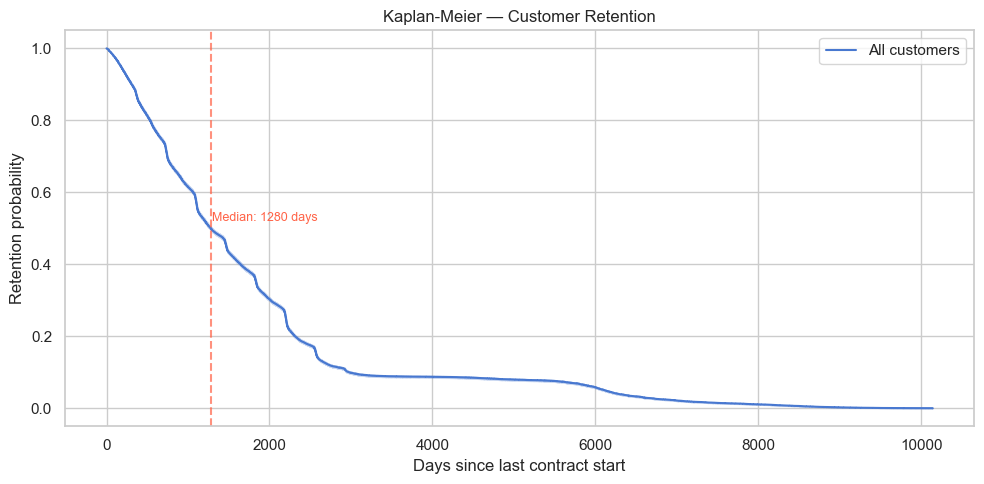

Median survival: 1280 days (42.0 months)

Retention probabilities:
    90 days: 97.8%
   180 days: 94.8%
   365 days: 87.2%
   730 days: 71.8%
  1460 days: 45.8%
  2920 days: 10.9%


In [14]:
# ── 1. Overall survival curve ────────────────────────────────────────────────
kmf = KaplanMeierFitter()
kmf.fit(
    durations=mask_pay["TIME_TO_CHURN_D"],
    event_observed=mask_pay["IS_CHURN"],
    label="All customers"
)

fig, ax = plt.subplots(figsize=(10, 5))
kmf.plot_survival_function(ax=ax, ci_show=True)
ax.set_xlabel("Days since last contract start")
ax.set_ylabel("Retention probability")
ax.set_title("Kaplan-Meier — Customer Retention")

# Annotate median survival time
median_t = kmf.median_survival_time_
ax.axvline(median_t, color='tomato', linestyle='--', alpha=0.7)
ax.text(median_t + 10, 0.52, f'Median: {median_t:.0f} days', color='tomato', fontsize=9)

plt.tight_layout()
plt.show()

# ── 2. Retention at key timepoints ───────────────────────────────────────────
timepoints = [90, 180, 365, 730, 1460, 2920]
print(f"Median survival: {kmf.median_survival_time_:.0f} days ({kmf.median_survival_time_/30.44:.1f} months)\n")
print("Retention probabilities:")
for t in timepoints:
    s = kmf.survival_function_at_times([t]).values[0]
    print(f"  {t:4d} days: {s:.1%}")


### Findings — Overall Retention

- Churn is a **slow-burn phenomenon** — 97.8% of customers are still retained at 90 days. There is no steep early drop.
- The **median of ~42 months (~3.5 years)** represents the typical contract lifetime before a customer does not return.
- Retention declines steadily after the first year: from 87% at 365 days to 72% at 730 days, and below 50% only after ~4 years.
- Note: `TIME_TO_CHURN_D` measures duration of the **last contract**, not total customer lifetime — customers with multiple contracts may have shorter or longer individual contract durations.

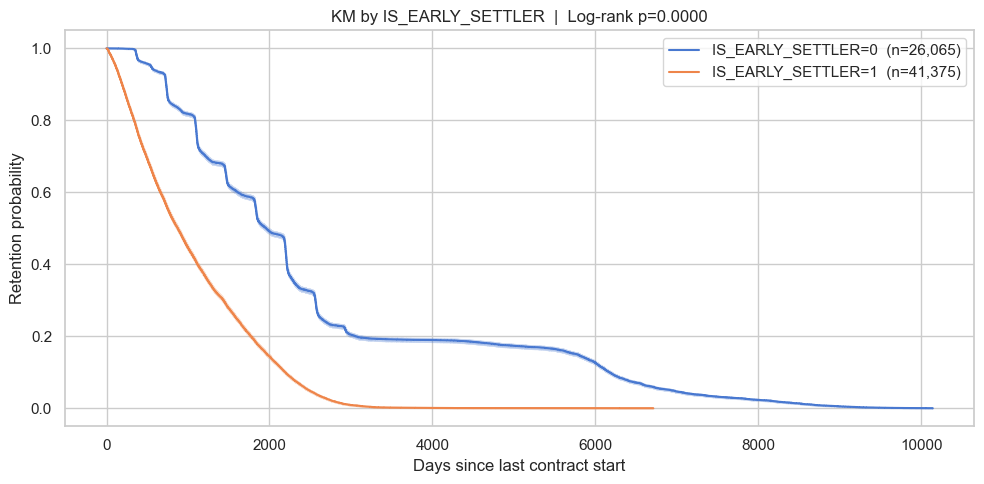

  SOL (on-time)             n=26,065  median=1959 days (64.4 months)
  SAN/RBT (early settler)   n=41,375  median=874 days (28.7 months)

  Log-rank p-value: 0.000000


In [15]:
# ── 3. Group comparisons with log-rank test ──────────────────────────────────

GROUP_COL = "IS_EARLY_SETTLER"  # 1 = early settler (SAN/RBT), 0 = on-time (SOL)

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_ylabel("Retention probability")

groups = mask_pay[GROUP_COL].unique()
kmf_list = []
for g in sorted(groups):
    subset = mask_pay[mask_pay[GROUP_COL] == g]
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(
        durations=subset["TIME_TO_CHURN_D"],
        event_observed=subset["IS_CHURN"],
        label=f"{GROUP_COL}={g}  (n={len(subset):,})"
    )
    kmf_g.plot_survival_function(ax=ax, ci_show=True)
    kmf_list.append((g, subset))

# Log-rank test between the two groups
# Is there a difference in the distribution of the time unitl an event occurs (Churn in this Case) for two diffrent samples?

if len(kmf_list) == 2:
    g0_data = kmf_list[0][1]
    g1_data = kmf_list[1][1]
    result = logrank_test(
        g0_data["TIME_TO_CHURN_D"], g1_data["TIME_TO_CHURN_D"],
        event_observed_A=g0_data["IS_CHURN"],
        event_observed_B=g1_data["IS_CHURN"]
    )
    ax.set_title(f"KM by {GROUP_COL}  |  Log-rank p={result.p_value:.4f}")
else:
    ax.set_title(f"KM by {GROUP_COL}")

ax.set_xlabel("Days since last contract start")
ax.set_ylabel("Retention probability")
plt.tight_layout()
plt.show()

for g, label in [(0, "SOL (on-time)"), (1, "SAN/RBT (early settler)")]:
    sub = mask_pay[mask_pay["IS_EARLY_SETTLER"] == g]
    kmf_g = KaplanMeierFitter()
    kmf_g.fit(sub["TIME_TO_CHURN_D"], event_observed=sub["IS_CHURN"])
    m = kmf_g.median_survival_time_
    print(f"  {label:<25} n={len(sub):,}  median={m:.0f} days ({m/30.44:.1f} months)")

g0 = mask_pay[mask_pay["IS_EARLY_SETTLER"] == 0]
g1 = mask_pay[mask_pay["IS_EARLY_SETTLER"] == 1]
lr = logrank_test(g0["TIME_TO_CHURN_D"], g1["TIME_TO_CHURN_D"],
                  event_observed_A=g0["IS_CHURN"], event_observed_B=g1["IS_CHURN"])
print(f"\n  Log-rank p-value: {lr.p_value:.6f}")


### Findings — Settlement Type Comparison

- **Settlement type remains the strongest stratifying factor** — early settlers (SAN/RBT) churn **2.2× faster** than on-time settlers (SOL).
- Customers who exit contracts early are fundamentally different in behaviour.
- The log-rank test (p ≈ 0) confirms the difference is not random — the two survival curves are statistically distinct.

---
## 3. COX PROPORTIONAL HAZARDS MODEL

### Concept

The **Cox Proportional Hazards (Cox PH) model** is a semi-parametric regression model that estimates the effect of features on the *hazard rate* — the instantaneous risk of churning at time *t*, given survival up to that point.

$$h(t \mid x) = h_0(t) \cdot \exp(\beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p)$$

Where:
- $h_0(t)$ is the **baseline hazard** — the underlying churn risk shared by all customers (non-parametric, never estimated directly).
- $\exp(\beta_i)$ is the **hazard ratio (HR)** for feature $x_i$.
- The model is **semi-parametric**: it makes no assumption about the shape of $h_0(t)$, but assumes that features shift the hazard *multiplicatively* and *proportionally over time*.

**How to read hazard ratios:**

| HR | Meaning |
|----|---------|
| HR = 1.0 | No effect on churn risk |
| HR = 1.4 | 40% *higher* churn hazard per unit increase in the feature |
| HR = 0.97 | 3% *lower* churn hazard per unit increase in the feature |

**Key assumptions:**
- **Proportional hazards** — the ratio of hazards between any two customers is constant over time. Violated if, e.g., a feature only matters early in the contract.
- **Log-linearity** — the log-hazard is a linear combination of features.
- **No multicollinearity** — addressed here via L2 regularisation (`penalizer=0.1`).

**Concordance index (C-index):**
Equivalent to AUC for survival models.  
Measures whether the model correctly ranks pairs of customers by their churn risk.  
C-index = 0.5 is random; 1.0 is perfect discrimination.

**Difference from Kaplan-Meier:**
KM describes *what* the population-level survival looks like.  
Cox PH explains *why* — which features drive faster or slower churn — while controlling for all other features simultaneously.

In [16]:
# ── 1. Prepare Cox DataFrame ─────────────────────────────────────────────────
# prep_df from Section 1.5 already has: outlier handling, imputation, OHE applied.
# Drop any remaining zero-variance columns (safety check after OHE).
cox_df = prep_df.loc[:, prep_df.std() > 0].copy()

print(f"Features for Cox model: {len(cox_df.columns) - 2}")
print(cox_df.shape)

Features for Cox model: 90
(67440, 92)


In [17]:
# ── 2. Fit Cox PH model ──────────────────────────────────────────────────────
cph = CoxPHFitter(penalizer=0.1)  # L2 regularization to handle correlated features
cph.fit(
    cox_df,
    duration_col="TIME_TO_CHURN_D",
    event_col="IS_CHURN",
    show_progress=True
)

cph.print_summary()

/Users/eliaskarle/Coding/Nova/BusinessCases_1/Business_Case_BNP/.venv/lib/python3.11/site-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['sdem_HABITAT_0'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


Iteration 1: norm_delta = 7.86e-01, step_size = 0.9500, log_lik = -489035.02525, newton_decrement = 2.24e+04, seconds_since_start = 0.5
Iteration 2: norm_delta = 1.34e-01, step_size = 0.9500, log_lik = -466539.04486, newton_decrement = 7.34e+02, seconds_since_start = 0.9
Iteration 3: norm_delta = 2.21e-02, step_size = 0.9500, log_lik = -465761.11658, newton_decrement = 5.21e+01, seconds_since_start = 1.4
Iteration 4: norm_delta = 8.34e-03, step_size = 1.0000, log_lik = -465700.51385, newton_decrement = 5.62e+00, seconds_since_start = 1.8
Iteration 5: norm_delta = 1.31e-03, step_size = 1.0000, log_lik = -465694.42944, newton_decrement = 1.07e-01, seconds_since_start = 2.2
Iteration 6: norm_delta = 2.63e-05, step_size = 1.0000, log_lik = -465694.32071, newton_decrement = 4.18e-05, seconds_since_start = 2.6
Iteration 7: norm_delta = 1.03e-08, step_size = 1.0000, log_lik = -465694.32066, newton_decrement = 6.37e-12, seconds_since_start = 3.2
Convergence success after 7 iterations.


<lifelines.CoxPHFitter: fitted with 67440 total observations, 17707 right-censored observations>
             duration col = 'TIME_TO_CHURN_D'
                event col = 'IS_CHURN'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 67440
number of events observed = 49733
   partial log-likelihood = -465694.32
         time fit was run = 2026-03-16 17:48:29 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
N_CONTRACTS           0.08      1.09      0.01            0.06            0.10                1.06                1.11
MIN_DURDEG           -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MAX_DURDEG           -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
MEDIAN_DURDEG        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MIN_RANGPRO          -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
MAX_RANGPRO          -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
MEDIAN_RANGPRO       -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
MIN_RANGCLI           0.00      1.00      0.00            0.00            0.00                1.00                1.00
MAX_RANGCLI           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
MEDIAN_RANGCLI        0.00      1.00      0.00            0.00            0.00                1.00                1.00
TOTAL_MTFIN          -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
TOTAL_MTFINO         -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
TOTAL_MENSALIDADE    -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MIN_RESSO             0.00      1.00      0.00            0.00            0.00                1.00                1.00
MAX_RESSO             0.00      1.00      0.00            0.00            0.00                1.00                1.00
MEDIAN_RESSO          0.00      1.00      0.00            0.00            0.00                1.00                1.00
NBENF                -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
MT_MENSAL_MEDIAN      0.00      1.00      0.00            0.00            0.00                1.00                1.00
COUNT_CL_MEDIAN       0.03      1.03      0.01            0.02            0.04                1.02                1.04
COUNT_AUTO_MEDIAN     0.12      1.13      0.01            0.10            0.14                1.11                1.15
COUNT_TOTAL_MEDIAN   -0.05      0.95      0.00           -0.05           -0.05                0.95                0.96
MONTVENC_CL_MEDIAN   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MONTVENC_CP_MEDIAN   -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MONTVENC_AUTO_MEDIAN -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
MONTVENC_HT_MEDIAN   -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
DIVIDAS_CL_MEDIAN     0.00      1.00      0.00            0.00            0.00                1.00                1.00
DIVIDAS_CP_MEDIAN     0.00      1.00      0.00            0.00            0.00                1.00                1.00
DIVIDAS_AUTO_MEDIAN  -0.00      1.00      0.00           -0.00           -0.00                1.00     

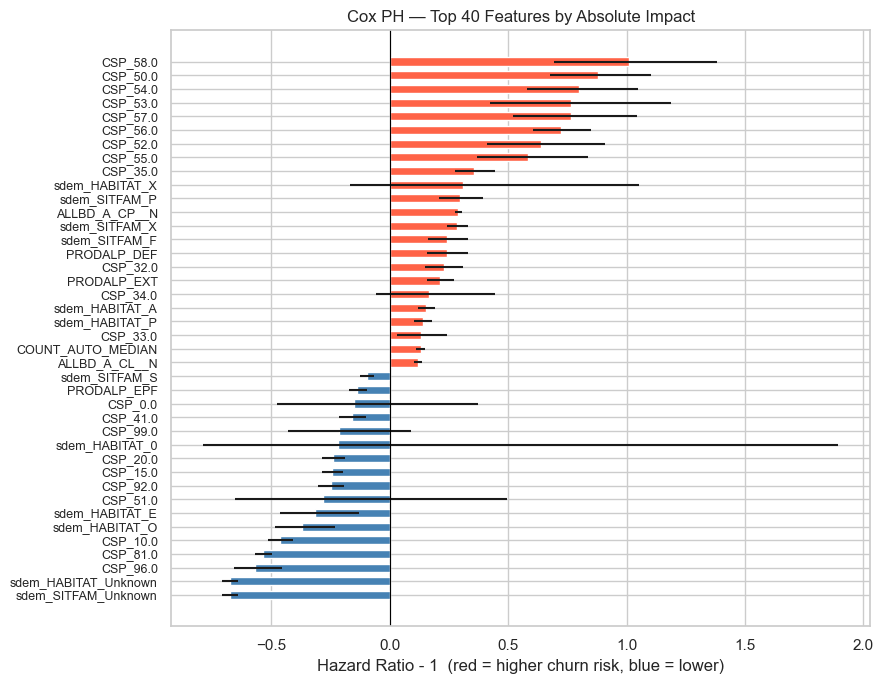

In [22]:
# ── 3. Hazard ratio plot (top 40 features) ───────────────────────────────────
hr = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()

# 3.1 Calculate the magnitude of the impact (absolute log hazard ratio)
hr["abs_impact"] = np.abs(np.log(hr["exp(coef)"]))

# 3.2 Get the top 40 most impactful features in both directions
hr = hr.sort_values("abs_impact", ascending=False).head(40)

# 3.3. Re-sort by exp(coef) 
hr = hr.sort_values("exp(coef)", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
y_pos = range(len(hr))

ax.barh(y_pos, hr["exp(coef)"] - 1,
        xerr=[hr["exp(coef)"] - hr["exp(coef) lower 95%"],
              hr["exp(coef) upper 95%"] - hr["exp(coef)"]],
        color=["tomato" if v > 1 else "steelblue" for v in hr["exp(coef)"]],
        edgecolor="white", height=0.6)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(hr.index, fontsize=9)
ax.set_xlabel("Hazard Ratio - 1  (red = higher churn risk, blue = lower)")
ax.set_title("Cox PH — Top 40 Features by Absolute Impact")
plt.tight_layout()
plt.show()


In [27]:
# ── 3.4 Cox summary — C-index + top hazard ratios ──────────────────────────────
print(f"C-index: {cph.concordance_index_:.4f}\n")

summary = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]].copy()
summary.columns = ["HR", "HR_lo", "HR_hi", "p"]

print("Top 20 churn RISK drivers (HR > 1):")
for feat, row in summary.sort_values("HR", ascending=False).head(20).iterrows():
    sig = "***" if row["p"] < 0.001 else "**" if row["p"] < 0.01 else "*" if row["p"] < 0.05 else ""
    print(f"  {feat:<35} HR={row['HR']:.3f}  [{row['HR_lo']:.3f}-{row['HR_hi']:.3f}]  p={row['p']:.4f} {sig}")


C-index: 0.8369

Top 20 churn RISK drivers (HR > 1):
  CSP_58.0                            HR=2.008  [1.692-2.384]  p=0.0000 ***
  CSP_50.0                            HR=1.880  [1.679-2.105]  p=0.0000 ***
  CSP_54.0                            HR=1.799  [1.580-2.048]  p=0.0000 ***
  CSP_53.0                            HR=1.764  [1.422-2.187]  p=0.0000 ***
  CSP_57.0                            HR=1.764  [1.520-2.046]  p=0.0000 ***
  CSP_56.0                            HR=1.722  [1.604-1.848]  p=0.0000 ***
  CSP_52.0                            HR=1.640  [1.410-1.908]  p=0.0000 ***
  CSP_55.0                            HR=1.586  [1.368-1.839]  p=0.0000 ***
  CSP_35.0                            HR=1.357  [1.274-1.445]  p=0.0000 ***
  sdem_HABITAT_X                      HR=1.308  [0.834-2.053]  p=0.2420 
  sdem_SITFAM_P                       HR=1.297  [1.207-1.393]  p=0.0000 ***
  ALLBD_A_CP__N                       HR=1.290  [1.275-1.305]  p=0.0000 ***
  sdem_SITFAM_X                       

In [28]:
print("\nTop 20 churn PROTECTION drivers (HR < 1):")
for feat, row in summary.sort_values("HR").head(20).iterrows():
    sig = "***" if row["p"] < 0.001 else "**" if row["p"] < 0.01 else "*" if row["p"] < 0.05 else ""
    print(f"  {feat:<35} HR={row['HR']:.3f}  [{row['HR_lo']:.3f}-{row['HR_hi']:.3f}]  p={row['p']:.4f} {sig}")


Top 20 churn PROTECTION drivers (HR < 1):
  sdem_HABITAT_Unknown                HR=0.325  [0.292-0.361]  p=0.0000 ***
  sdem_SITFAM_Unknown                 HR=0.325  [0.292-0.361]  p=0.0000 ***
  CSP_96.0                            HR=0.433  [0.344-0.544]  p=0.0000 ***
  CSP_81.0                            HR=0.466  [0.431-0.504]  p=0.0000 ***
  CSP_10.0                            HR=0.537  [0.486-0.594]  p=0.0000 ***
  sdem_HABITAT_O                      HR=0.630  [0.514-0.771]  p=0.0000 ***
  sdem_HABITAT_E                      HR=0.684  [0.538-0.870]  p=0.0019 **
  CSP_51.0                            HR=0.719  [0.346-1.495]  p=0.3776 
  CSP_92.0                            HR=0.752  [0.699-0.808]  p=0.0000 ***
  CSP_15.0                            HR=0.756  [0.712-0.802]  p=0.0000 ***
  CSP_20.0                            HR=0.761  [0.714-0.811]  p=0.0000 ***
  sdem_HABITAT_0                      HR=0.783  [0.212-2.895]  p=0.7133 
  CSP_99.0                            HR=0.788  [0.5

### 3. Findings — Cox PH Model


#### Churn risk drivers (HR > 1)

| Feature | HR | CI 95% | Significance | Interpretation |
|---------|-----|--------|---|----------------|
| `CSP_58` | 2.030 | [1.692–2.384] | *** | Unlabeled CSP subcategory — **2× higher churn hazard** vs reference group |
| `CSP_50` | 1.863 | [1.679–2.105] | *** | Unlabeled CSP subcategory |
| `CSP_54` | 1.771 | [1.580–2.048] | *** | Unlabeled CSP subcategory |
| `CSP_57` | 1.759 | [1.520–2.046] | *** | Unlabeled CSP subcategory |
| `CSP_56` | 1.718 | [1.604–1.848] | *** | Other (CSP 56) |
| `CSP_53` | 1.713 | [1.422–2.187] | *** | Unlabeled CSP subcategory |
| `CSP_52` | 1.629 | [1.410–1.908] | *** | Unlabeled CSP subcategory |
| `CSP_55` | 1.565 | [1.368–1.839] | *** | Unlabeled CSP subcategory |
| `CSP_35` | 1.349 | [1.274–1.445] | *** | **Teachers** — 35% higher churn hazard |
| `sdem_HABITAT_X` | 1.308 | [0.834–2.053] | n.s. | Housing: Unknown — not statistically significant |
| `sdem_SITFAM_P` | 1.297 | [1.207–1.393] | *** | Family situation: P (undocumented code — not in official data dictionary) |
| `ALLBD_A_CP__N` | 1.290 | [1.275–1.305] | *** | N° active personal credit (CP) contracts within BNP Group — each additional contract raises hazard ~29% |
| `sdem_SITFAM_X` | 1.286 | [1.243–1.331] | *** | Family situation: Other/Unknown |
| `sdem_SITFAM_F` | 1.244 | [1.164–1.329] | *** | Family situation: F (undocumented code — not in official data dictionary) |
| `PRODALP_DEF` | 1.241 | [1.157–1.331] | *** | Product code DEF (internal catalogue — meaning unknown) |
| `CSP_32` | 1.229 | [1.151–1.311] | *** | **Health Professionals** — 23% higher churn hazard |
| `PRODALP_EXT` | 1.213 | [1.156–1.273] | *** | Product code EXT (internal catalogue — meaning unknown) |
| `CSP_34` | 1.166 | [0.942–1.444] | n.s. | Doctor — not statistically significant |
| `sdem_HABITAT_A` | 1.155 | [1.119–1.191] | *** | **Housing: Property Loan** — customers with an existing property loan churn more |
| `sdem_HABITAT_P` | 1.141 | [1.105–1.178] | *** | **Housing: Owner** — homeowners show higher churn hazard |

The 50–58 CSP block dominates risk — these codes are not in the current label dictionary and cannot be interpreted.  
`SITFAM_P` and `SITFAM_F` appear in the data but are undocumented (not in official BNP data dictionary).  
`PRODALP_DEF` and `PRODALP_EXT` are internal product codes whose business meaning is currently unknown.




#### Churn protection drivers (HR < 1)

| Feature | HR | CI 95% | Sig. | Interpretation |
|---------|-----|--------|------|----------------|
| `sdem_HABITAT_Unknown` | 0.325 | [0.292–0.361] | *** | ⚠️ Imputation artifact — `NaN` housing type filled with `"Unknown"` by `ClientImputer`. Not a real customer segment. |
| `sdem_SITFAM_Unknown` | 0.325 | [0.292–0.361] | *** | ⚠️ Imputation artifact — `NaN` marital status filled with `"Unknown"` by `ClientImputer`. Not a real customer segment. |
| `CSP_96` | 0.433 | [0.344–0.544] | *** | **Fixed-term contract** workers — lower churn risk, possibly more dependent on recurring financing |
| `CSP_81` | 0.466 | [0.431–0.504] | *** | **Driver-Security** workers — lower churn risk |
| `CSP_10` | 0.537 | [0.486–0.594] | *** | **Merchants** — lower churn risk, likely stable recurring borrowing needs |
| `sdem_HABITAT_O` | 0.630 | [0.514–0.771] | *** | **Other housing** — lower churn risk vs reference |
| `sdem_HABITAT_E` | 0.684 | [0.538–0.870] | ** | **Employer housing** — lower churn risk |
| `CSP_51` | 0.719 | [0.346–1.495] | n.s. | Unlabeled CSP subcategory — not statistically significant |
| `CSP_92` | 0.752 | [0.699–0.808] | *** | **Unemployed** — lower churn risk, possibly reliant on continued credit access |
| `CSP_15` | 0.756 | [0.712–0.802] | *** | **Service Providers** — lower churn risk |
| `CSP_20` | 0.761 | [0.714–0.811] | *** | **Managing Partners** — lower churn risk |
| `sdem_HABITAT_0` | 0.783 | [0.212–2.895] | n.s. | ⚠️ Likely OHE artifact (numeric code 0 — not in official HABITAT dictionary). Not statistically significant. |
| `CSP_99` | 0.788 | [0.570–1.089] | n.s. | **Indeterminate** CSP — not statistically significant |
| `CSP_41` | 0.841 | [0.785–0.900] | *** | **Public Dept Heads** — lower churn risk |
| `CSP_0` | 0.850 | [0.526–1.374] | n.s. | ⚠️ Likely OHE artifact (numeric code 0 — not in official CSP dictionary). Not statistically significant. |
| `PRODALP_EPF` | 0.864 | [0.827–0.903] | *** | Product code EPF (internal catalogue — meaning unknown) |
| `sdem_SITFAM_S` | 0.905 | [0.876–0.936] | *** | **Single** — lower churn risk |
| `CSP_86` | 0.911 | [0.810–1.024] | n.s. | **Cleaning Staff** — not statistically significant |
| `sdem_HABITAT_L` | 0.913 | [0.880–0.948] | *** | **Tenant/Rental** — lower churn risk vs homeowners |
| `CSP_60` | 0.914 | [0.886–0.943] | *** | **Office Employees** — lower churn risk |


**Treat `_Unknown` dummies with caution** — HR=0.332 for both imputed unknowns is a data artifact, not a real signal.

---
## 4. SUMMARY

### Key Findings

| Finding | Detail |
|---------|--------|
| **Population** | 67,440 customers (mask_pay) — 73.7% churned, 26.3% returned |
| **Cox C-index** | 0.837 — good discrimination of churn risk |
| **Median time-to-churn** | 1,280 days (~42 months) from last contract start |
| **Dominant stratifier** | Settlement type: early settlers (SAN/RBT) churn **2.2× faster** than on-time settlers (SOL) — median 874 vs 1,959 days |
| **Top risk drivers** | CSP codes 50–58 (unlabeled, HR 1.6–2.0), CSP_35 Teachers (HR 1.35), active CP contracts `ALLBD_A_CP__N` (HR 1.29) |
| **Top protective factors** | CSP_96 Fixed-term workers (HR 0.43), CSP_81 Driver-Security (HR 0.47), CSP_10 Merchants (HR 0.54), Tenants/Rental housing (HR 0.91), Single marital status (HR 0.91) |
| **Key open question** | CSP codes 50–58 dominate risk but are unlabeled — cannot be interpreted without internal catalogue |
| **Data quality flags** | `_Unknown` OHE dummies (HR 0.33) are imputation artifacts; 

In [23]:
print("=" * 50)
print("SURVIVAL ANALYSIS SUMMARY")
print("=" * 50)
print(f"Population:          {len(mask_pay):,} customers (mask_pay)")
print(f"Churn events:        {mask_pay['IS_CHURN'].sum():,} ({mask_pay['IS_CHURN'].mean():.1%})")
print(f"Median survival:     {kmf.median_survival_time_:.0f} days"
      f" ({kmf.median_survival_time_/30.44:.1f} months)")
print()
print("Top 5 features increasing churn risk (HR > 1):")
top_risk = cph.summary["exp(coef)"].sort_values(ascending=False).head(5)
for feat, hr_val in top_risk.items():
    print(f"  {feat:<30} HR = {hr_val:.3f}")
print()
print("Top 5 features decreasing churn risk (HR < 1):")
top_protect = cph.summary["exp(coef)"].sort_values().head(5)
for feat, hr_val in top_protect.items():
    print(f"  {feat:<30} HR = {hr_val:.3f}")

SURVIVAL ANALYSIS SUMMARY
Population:          67,440 customers (mask_pay)
Churn events:        49,733 (73.7%)
Median survival:     1280 days (42.0 months)

Top 5 features increasing churn risk (HR > 1):
  CSP_58.0                       HR = 2.008
  CSP_50.0                       HR = 1.880
  CSP_54.0                       HR = 1.799
  CSP_53.0                       HR = 1.764
  CSP_57.0                       HR = 1.764

Top 5 features decreasing churn risk (HR < 1):
  sdem_HABITAT_Unknown           HR = 0.325
  sdem_SITFAM_Unknown            HR = 0.325
  CSP_96.0                       HR = 0.433
  CSP_81.0                       HR = 0.466
  CSP_10.0                       HR = 0.537
